In [2]:
import pandas as pd

df = pd.read_csv("wandb_csv_augmentations.csv")

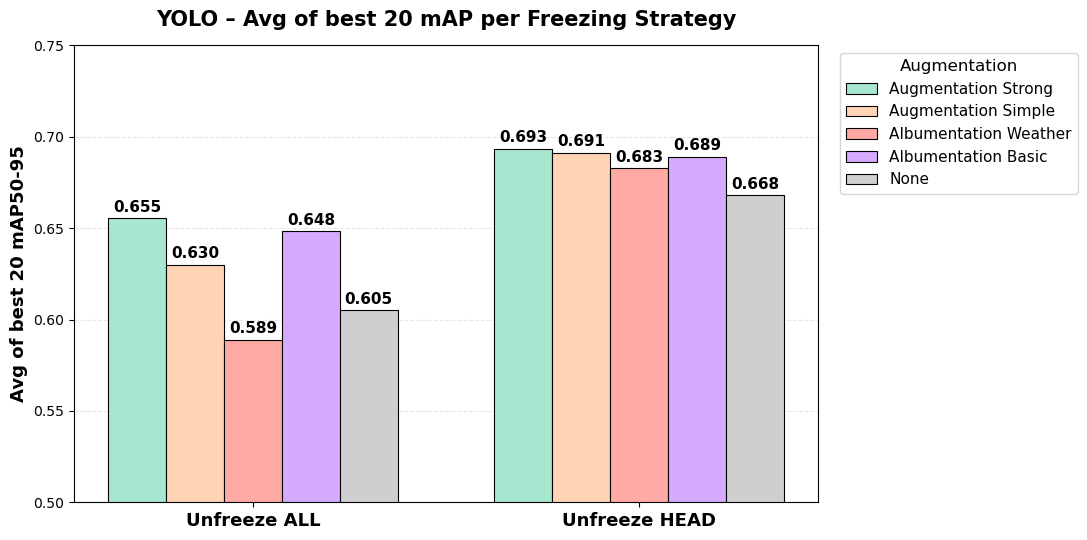

In [19]:
import re
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

csv_path = "wandb_csv_augmentations.csv"

# 1) Read CSV
df = pd.read_csv(csv_path)

# 2) Select only the "main" metric columns (exclude __MIN/__MAX and Step)
metric_cols = [
    c for c in df.columns
    if c != "Step" and not c.endswith("__MIN") and not c.endswith("__MAX")
]

# --- NEW: average of best 10 (top-10 mean) per column ---
K = 20

def topk_mean(series: pd.Series, k: int = 10) -> float:
    s = pd.to_numeric(series, errors="coerce").dropna()
    if s.empty:
        return np.nan
    k = min(k, len(s))  # if fewer than k steps exist
    return float(s.nlargest(k).mean())

score = {c: topk_mean(df[c], K) for c in metric_cols}
best_map = pd.Series(score)  # index=column_name, value=avg of best K

# 3) Parse column names into freeze + augmentation
def parse_experiment(colname: str):
    left = colname.split(" - ")[0]

    if left.startswith("yolo_unfz_all"):
        freeze = "yolo_unfz_all"
        rest = left[len("yolo_unfz_all"):]
    elif left.startswith("yolo_unfz_head"):
        freeze = "yolo_unfz_head"
        rest = left[len("yolo_unfz_head"):]
    else:
        return None

    rest = rest.lstrip("_")
    aug = "none" if rest == "" else rest
    return freeze, aug

records = []
for col, best10avg in best_map.items():
    parsed = parse_experiment(col)
    if parsed is None:
        continue
    freeze, aug = parsed
    records.append({"freeze": freeze, "aug": aug, "best10_avg_mAP": float(best10avg), "col": col})

best_df = pd.DataFrame(records)

# 4) Ensure exactly the 5 bars per freeze in the order you want
aug_order = [
    "augmentation_strong",
    "augmentation_simple",
    "albumentation_weather",
    "albumentation_basic",
    "none",
]

freeze_order = ["yolo_unfz_all", "yolo_unfz_head"]

table = (
    best_df.pivot_table(index="freeze", columns="aug", values="best10_avg_mAP", aggfunc="max")
    .reindex(index=freeze_order, columns=aug_order)
)
# 5) Plot grouped bars: 2 x-groups, 5 bars each
x = np.arange(len(freeze_order))
width = 0.15

plt.figure(figsize=(11, 5.5))

# Pastel color palette
pastel_colors = {
    "augmentation_strong": "#A8E6CF",       # pastel mint
    "augmentation_simple": "#FFD3B6",       # pastel peach
    "albumentation_weather": "#FFAAA5",     # pastel coral
    "albumentation_basic": "#D5AAFF",       # pastel lavender
    "none": "#CFCFCF",                      # pastel gray
}

for i, aug in enumerate(aug_order):
    y = table[aug].values
    xpos = x + (i - (len(aug_order)-1)/2) * width

    bars = plt.bar(
        xpos, y, width,
        label=aug.replace("_", " ").title(),
        color=pastel_colors[aug],
        edgecolor="black",
        linewidth=0.8
    )

    # Value labels (3 decimals, bigger text)
    for b in bars:
        h = b.get_height()
        if np.isfinite(h):
            plt.text(
                b.get_x() + b.get_width()/2,
                h + 0.002,
                f"{h:.3f}",
                ha="center",
                va="bottom",
                fontsize=11,
                fontweight="bold"
            )

# Styling for slide visibility
plt.xticks(x, ["Unfreeze ALL", "Unfreeze HEAD"], fontsize=13, fontweight="bold")
plt.ylim(0.5, 0.75)
plt.ylabel(f"Avg of best {K} mAP50-95", fontsize=13, fontweight="bold")
plt.title(
    f"YOLO – Avg of best {K} mAP per Freezing Strategy",
    fontsize=15,
    fontweight="bold",
    pad=14
)

plt.grid(axis="y", linestyle="--", alpha=0.3)
plt.gca().set_axisbelow(True)

plt.legend(
    title="Augmentation",
    fontsize=11,
    title_fontsize=12,
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
    frameon=True
)

plt.tight_layout()
plt.show()

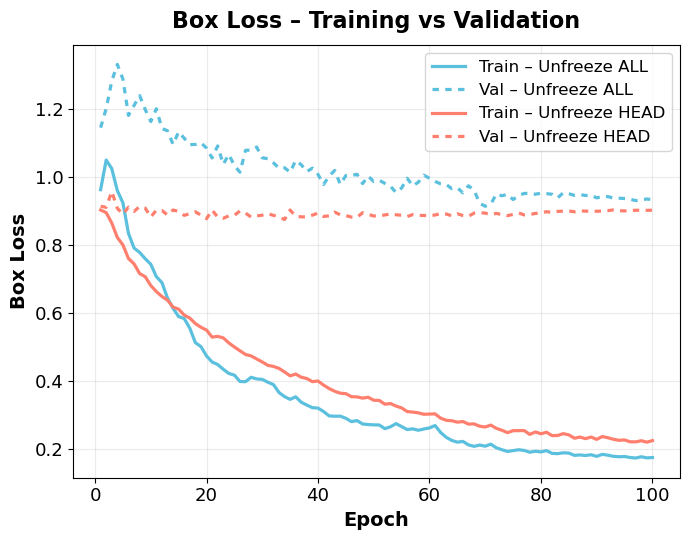

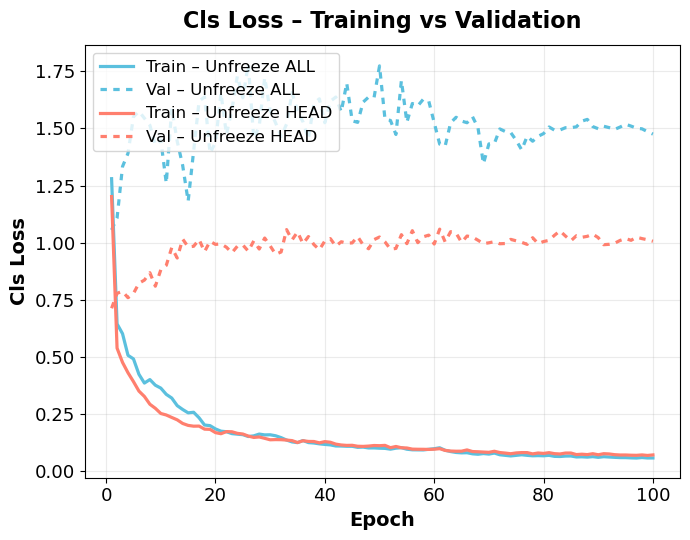

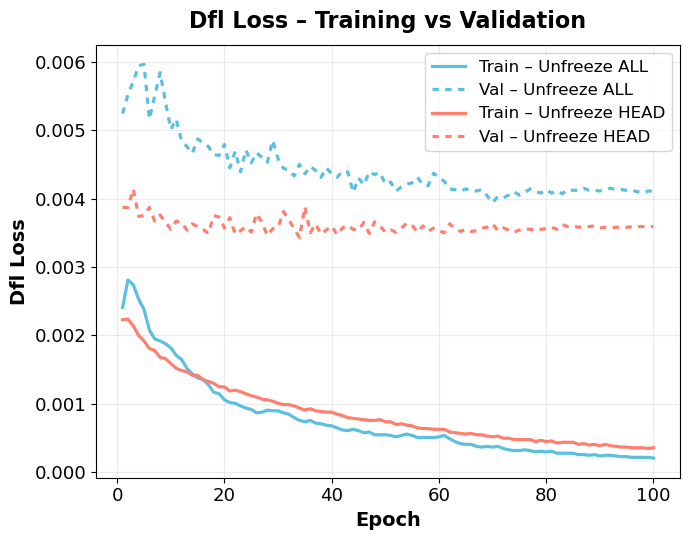

In [32]:
import pandas as pd
import matplotlib.pyplot as plt

csv_path = "wandb_csv_valtrainloss_head_all.csv"
df = pd.read_csv(csv_path)

# Keep only main columns (exclude __MIN/__MAX)
df = df[[c for c in df.columns if not c.endswith("__MIN") and not c.endswith("__MAX")]]

# Ensure Step is numeric and sorted (important for interpolation)
df["Step"] = pd.to_numeric(df["Step"], errors="coerce")
df = df.sort_values("Step").reset_index(drop=True)

loss_types = ["box_loss", "cls_loss", "dfl_loss"]

# Two consistent colors: one per unfreeze strategy
colors = {
    "all":  "#5BC0DE",   # medium cyan
    "head": "#FF7F6E",   # softened tomato
}
# Short, frequent dash pattern (on, off) in points
short_dashes = (0, (2, 2))  # smaller dashes than default

def continuous(series: pd.Series) -> pd.Series:
    """Fill missing values to keep lines continuous."""
    s = pd.to_numeric(series, errors="coerce")
    # Interpolate across internal gaps; then fill ends if needed
    s = s.interpolate(method="linear", limit_direction="both")
    return s

for loss in loss_types:
    plt.figure(figsize=(7, 5.5))

    # Column names
    all_train  = f"yolo_unfz_all - train/{loss}"
    all_val    = f"yolo_unfz_all - val/{loss}"
    head_train = f"yolo_unfz_head - train/{loss}"
    head_val   = f"yolo_unfz_head - val/{loss}"

    # Make series continuous (bridge missing values)
    y_all_train  = continuous(df[all_train])
    y_all_val    = continuous(df[all_val])
    y_head_train = continuous(df[head_train])
    y_head_val   = continuous(df[head_val])

    # Plot:
    # Same color per unfreeze strategy
    # Solid = Train, Short-dashed = Val
    plt.plot(df["Step"], y_all_train,  label="Train – Unfreeze ALL",  linewidth=2.3, color=colors["all"])
    plt.plot(df["Step"], y_all_val,    label="Val – Unfreeze ALL",    linewidth=2.3, color=colors["all"], linestyle=short_dashes)

    plt.plot(df["Step"], y_head_train, label="Train – Unfreeze HEAD", linewidth=2.3, color=colors["head"])
    plt.plot(df["Step"], y_head_val,   label="Val – Unfreeze HEAD",   linewidth=2.3, color=colors["head"], linestyle=short_dashes)

    # Styling (slide-friendly)
    plt.xlabel("Epoch", fontsize=14, fontweight="bold")
    plt.ylabel(loss.replace("_", " ").title(), fontsize=14, fontweight="bold")
    plt.title(f"{loss.replace('_',' ').title()} – Training vs Validation",
              fontsize=16, fontweight="bold", pad=12)

    plt.xticks(fontsize=13)
    plt.yticks(fontsize=13)

    plt.grid(alpha=0.25)
    plt.legend(fontsize=12, frameon=True)
    plt.tight_layout()
    plt.show()

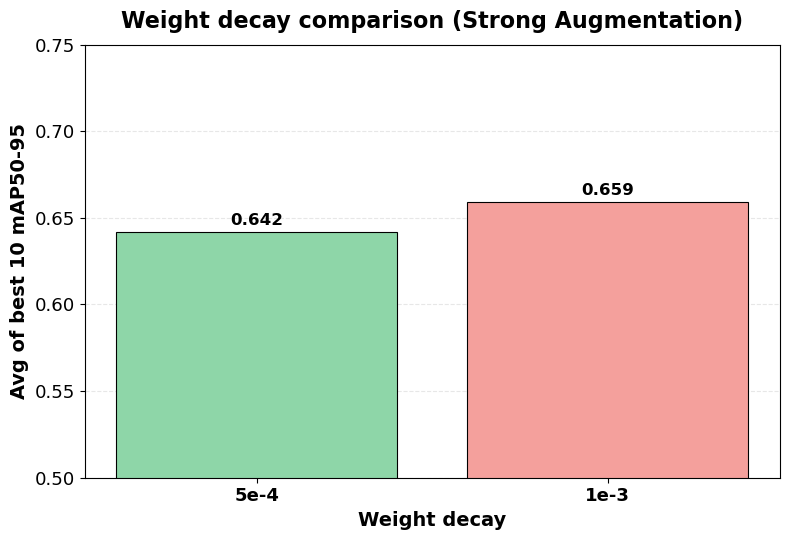

Top-K averages: {'1e-3': 0.659343, '5e-4': 0.6420860000000002}
Using columns:
 - yolo_unfz_all_augmentation_strong - metrics/mAP50-95(B) 
 - yolo_augmentation_strong_weight_decay_1e-3 - metrics/mAP50-95(B)


In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

csv_path = "wandb_csv_weight_decay_vs_strong.csv"  # <-- change
K = 10  # <-- choose K

df = pd.read_csv(csv_path)

# Ensure Step is numeric
df["Step"] = pd.to_numeric(df["Step"], errors="coerce")

# Keep only steps <= 50
df = df[df["Step"] <= 50].copy()

# Keep only main columns (exclude __MIN/__MAX and Step)
metric_cols = [c for c in df.columns if c != "Step" and not c.endswith("__MIN") and not c.endswith("__MAX")]

def topk_mean(series: pd.Series, k: int) -> float:
    s = pd.to_numeric(series, errors="coerce").dropna()
    if s.empty:
        return np.nan
    return float(s.nlargest(min(k, len(s))).mean())

# Identify the two columns
col_wd_1e3 = [c for c in metric_cols if "weight_decay_1e-3" in c][0]
col_wd_5e4 = [c for c in metric_cols if "yolo_unfz_all_augmentation_strong" in c][0]  # baseline

scores = {
    "1e-3": topk_mean(df[col_wd_1e3], K),
    "5e-4": topk_mean(df[col_wd_5e4], K),
}

# --- Plot (same style: pastel, 3 decimals, big text) ---
labels = ["5e-4", "1e-3"]  # order as you want
values = [scores[l] for l in labels]

colors = {
    "5e-4": "#8ED6A8",  # soft cyan
    "1e-3": "#F4A09C",  # soft tomato
}

plt.figure(figsize=(8, 5.5))  # less horizontally large, slide-friendly

bars = plt.bar(
    labels,
    values,
    color=[colors[l] for l in labels],
    edgecolor="black",
    linewidth=0.8
)

# Value labels (3 decimals, larger font)
for b in bars:
    h = b.get_height()
    if np.isfinite(h):
        plt.text(
            b.get_x() + b.get_width()/2,
            h + 0.002,
            f"{h:.3f}",
            ha="center",
            va="bottom",
            fontsize=12,
            fontweight="bold"
        )

plt.ylim(0.5, 0.75)  # adjust if needed
plt.grid(axis="y", linestyle="--", alpha=0.3)
plt.gca().set_axisbelow(True)

plt.xlabel("Weight decay", fontsize=14, fontweight="bold")
plt.ylabel(f"Avg of best {K} mAP50-95", fontsize=14, fontweight="bold")
plt.title(f"Weight decay comparison (Strong Augmentation)", fontsize=16, fontweight="bold", pad=12)

plt.xticks(fontsize=13, fontweight="bold")
plt.yticks(fontsize=13)

plt.tight_layout()
plt.show()

print("Top-K averages:", scores)
print("Using columns:\n -", col_wd_5e4, "\n -", col_wd_1e3)

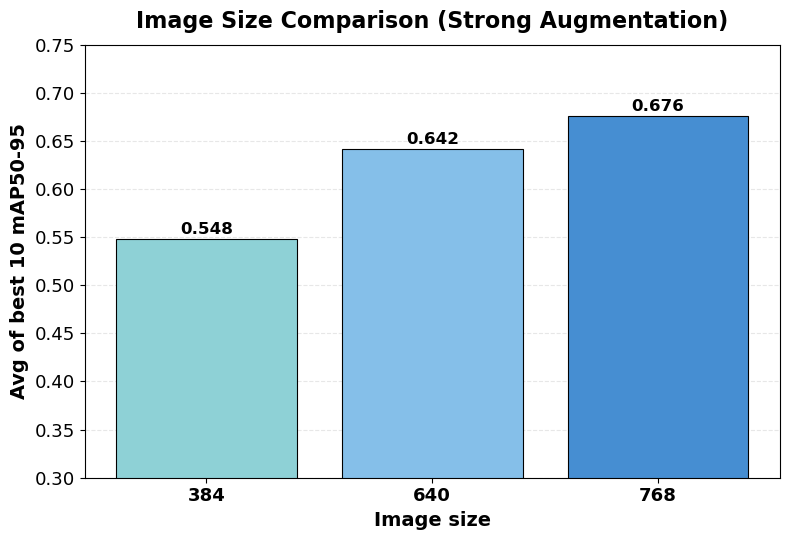

Top-K averages: {'384': 0.5483399999999999, '640': 0.6420860000000002, '768': 0.6760970000000001}


In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

csv_path = "wandb_csv_imgsz1.csv"  # <-- change
K = 10  # <-- choose K

df = pd.read_csv(csv_path)


# Ensure Step is numeric
df["Step"] = pd.to_numeric(df["Step"], errors="coerce")

# Keep only steps <= 50
df = df[df["Step"] <= 50].copy()

# Keep only main columns (exclude __MIN/__MAX and Step)
metric_cols = [c for c in df.columns if c != "Step" and not c.endswith("__MIN") and not c.endswith("__MAX")]

def topk_mean(series: pd.Series, k: int) -> float:
    s = pd.to_numeric(series, errors="coerce").dropna()
    if s.empty:
        return np.nan
    return float(s.nlargest(min(k, len(s))).mean())

# Identify columns
col_384 = [c for c in metric_cols if "lower_img_size" in c][0]
col_768 = [c for c in metric_cols if "higher_img_size" in c][0]
col_640 = [c for c in metric_cols if "yolo_unfz_all_augmentation_strong" in c][0]

scores = {
    "384": topk_mean(df[col_384], K),
    "640": topk_mean(df[col_640], K),
    "768": topk_mean(df[col_768], K),
}

# Order of bars
labels = ["384", "640", "768"]
values = [scores[l] for l in labels]

# Pastel colors (balanced and soft)
colors = {
    "384": "#8ED1D6",  # soft tomato
    "768": "#468ED2",  # soft gray (baseline)
    "640": "#85BFE9",  # soft cyan
}

plt.figure(figsize=(8, 5.5))

bars = plt.bar(
    labels,
    values,
    color=[colors[l] for l in labels],
    edgecolor="black",
    linewidth=0.8
)

# Value labels (3 decimals, bold)
for b in bars:
    h = b.get_height()
    if np.isfinite(h):
        plt.text(
            b.get_x() + b.get_width()/2,
            h + 0.002,
            f"{h:.3f}",
            ha="center",
            va="bottom",
            fontsize=12,
            fontweight="bold"
        )

plt.ylim(0.3, 0.75)  # adjust depending on values
plt.grid(axis="y", linestyle="--", alpha=0.3)
plt.gca().set_axisbelow(True)

plt.xlabel("Image size", fontsize=14, fontweight="bold")
plt.ylabel(f"Avg of best {K} mAP50-95", fontsize=14, fontweight="bold")
plt.title("Image Size Comparison (Strong Augmentation)", fontsize=16, fontweight="bold", pad=12)

plt.xticks(fontsize=13, fontweight="bold")
plt.yticks(fontsize=13)

plt.tight_layout()
plt.show()

print("Top-K averages:", scores)

In [13]:
import numpy as np
import pandas as pd

def wandb_twema(x: np.ndarray, y: np.ndarray, smoothing_param: float, viewport_scale: float = 1000.0):
    """
    W&B default smoothing: Time-Weighted EMA (TWEMA).
    Matches the reference implementation in W&B docs.
    smoothing_param in [0, 1].
    """
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)

    # smoothingWeight = min(sqrt(smoothingParam), 0.999)
    smoothing_weight = min(np.sqrt(max(smoothing_param, 0.0)), 0.999)

    # rangeOfX in their code (avoid divide by zero)
    range_of_x = np.nanmax(x) - np.nanmin(x)
    if not np.isfinite(range_of_x) or range_of_x == 0:
        range_of_x = 1.0

    last_y = 0.0
    debias_weight = 0.0
    out = np.empty_like(y, dtype=float)

    for i in range(len(y)):
        prev_i = i - 1 if i > 0 else 0
        change_in_x = ((x[i] - x[prev_i]) / range_of_x) * viewport_scale
        smoothing_weight_adj = smoothing_weight ** change_in_x

        # lastY = lastY * smoothingWeightAdj + yPoint
        last_y = last_y * smoothing_weight_adj + y[i]
        # debiasWeight = debiasWeight * smoothingWeightAdj + 1
        debias_weight = debias_weight * smoothing_weight_adj + 1.0

        out[i] = last_y / debias_weight

    return out

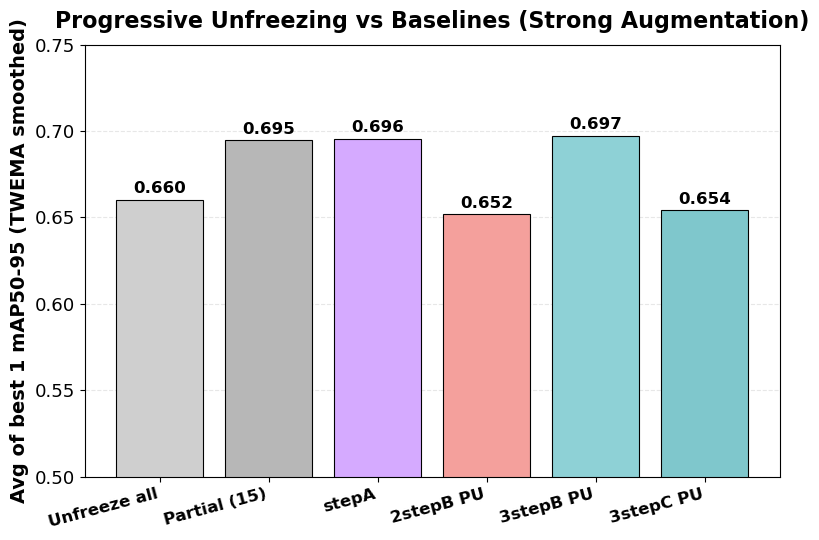

Top-K averages (TWEMA smoothed):
  Unfreeze all: 0.660261
  3stepC PU   : 0.654149
  2stepB PU   : 0.651952
  3stepB PU   : 0.697220
  stepA       : 0.695570
  Partial (15): 0.694755


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

csv_path = "wandb_csv_freezing_strategies2.csv"
K = 1

# --- NEW: W&B-style TWEMA smoothing (time-weighted EMA) ---
SMOOTHING = 0.6  # 0..1 like W&B slider (set to what you used in W&B)

def wandb_twema(x: np.ndarray, y: np.ndarray, smoothing_param: float, viewport_scale: float = 1000.0):
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)

    smoothing_weight = min(np.sqrt(max(smoothing_param, 0.0)), 0.999)

    range_of_x = np.nanmax(x) - np.nanmin(x)
    if not np.isfinite(range_of_x) or range_of_x == 0:
        range_of_x = 1.0

    last_y = 0.0
    debias_weight = 0.0
    out = np.empty_like(y, dtype=float)

    for i in range(len(y)):
        prev_i = i - 1 if i > 0 else 0
        change_in_x = ((x[i] - x[prev_i]) / range_of_x) * viewport_scale
        smoothing_weight_adj = smoothing_weight ** change_in_x

        last_y = last_y * smoothing_weight_adj + y[i]
        debias_weight = debias_weight * smoothing_weight_adj + 1.0
        out[i] = last_y / debias_weight

    return out

def smooth_series_twema(step_series: pd.Series, value_series: pd.Series, smoothing_param: float) -> pd.Series:
    x = pd.to_numeric(step_series, errors="coerce").to_numpy()
    y = pd.to_numeric(value_series, errors="coerce").to_numpy()

    mask = np.isfinite(x) & np.isfinite(y)
    ys = np.full_like(y, np.nan, dtype=float)
    if mask.sum() > 0:
        ys[mask] = wandb_twema(x[mask], y[mask], smoothing_param)
    return pd.Series(ys, index=value_series.index)
# --- END NEW ---

df = pd.read_csv(csv_path)

# (Optional) limit to step <= 50
# df["Step"] = pd.to_numeric(df["Step"], errors="coerce")
# df = df[df["Step"] <= 50].copy()

# Keep only main columns
metric_cols = [c for c in df.columns if c != "Step" and not c.endswith("__MIN") and not c.endswith("__MAX")]

# --- NEW: build a smoothed copy of the dataframe for metric columns ---
df_smooth = df.copy()
for c in metric_cols:
    df_smooth[c] = smooth_series_twema(df["Step"], df[c], SMOOTHING)
# --- END NEW ---

def topk_mean(series: pd.Series, k: int) -> float:
    s = pd.to_numeric(series, errors="coerce").dropna()
    if s.empty:
        return np.nan
    return float(s.nlargest(min(k, len(s))).mean())

def find_col(contains: str) -> str:
    matches = [c for c in metric_cols if contains in c]
    if not matches:
        raise ValueError(f'No column found containing: "{contains}"')
    if len(matches) > 1:
        print(f'Warning: multiple columns match "{contains}", using first:\n  {matches[0]}')
    return matches[0]

label_to_col = {
    "Unfreeze all": find_col("yolo_unfz_all_augmentation_strong"),
    "3stepC PU":    find_col("progressive_unfz_stageC2_freeze0"),
    "2stepB PU":    find_col("progressive_unfz_stageB1_freeze0"),
    "3stepB PU":    find_col("progressive_unfz_stageB2_freeze20"),
    "stepsA":        find_col("progressive_unfz_stageA"),
    "Partial (15)": find_col("yolo_strong_partial_freeze15"),
}

# --- CHANGED: compute scores from df_smooth instead of df ---
scores = {label: topk_mean(df_smooth[col], K) for label, col in label_to_col.items()}

labels = ["Unfreeze all", "Partial (15)", "stepsA", "2stepB PU", "3stepB PU", "3stepC PU"]
values = [scores[l] for l in labels]

colors = {
    "Unfreeze all": "#CFCFCF",
    "Partial (15)": "#B7B7B7",
    "stepsA":        "#D5AAFF",
    "2stepB PU":    "#F4A09C",
    "3stepB PU":    "#8ED1D6",
    "3stepC PU":    "#7FC7CC",
}

plt.figure(figsize=(8, 5.5))

bars = plt.bar(labels, values, color=[colors[l] for l in labels], edgecolor="black", linewidth=0.8)

for b in bars:
    h = b.get_height()
    if np.isfinite(h):
        plt.text(b.get_x() + b.get_width()/2, h + 0.002, f"{h:.3f}",
                 ha="center", va="bottom", fontsize=12, fontweight="bold")

plt.grid(axis="y", linestyle="--", alpha=0.3)
plt.gca().set_axisbelow(True)

plt.ylabel(f"Avg of best {K} mAP50-95 (TWEMA smoothed)", fontsize=14, fontweight="bold")
plt.title("Progressive Unfreezing vs Baselines (Strong Augmentation)", fontsize=16, fontweight="bold", pad=12)
plt.xticks(fontsize=12, fontweight="bold", rotation=15, ha="right")
plt.yticks(fontsize=13)
plt.ylim(0.5, 0.75)
plt.tight_layout()
plt.show()

print("Top-K averages (TWEMA smoothed):")
for k, v in scores.items():
    print(f"  {k:12s}: {v:.6f}")

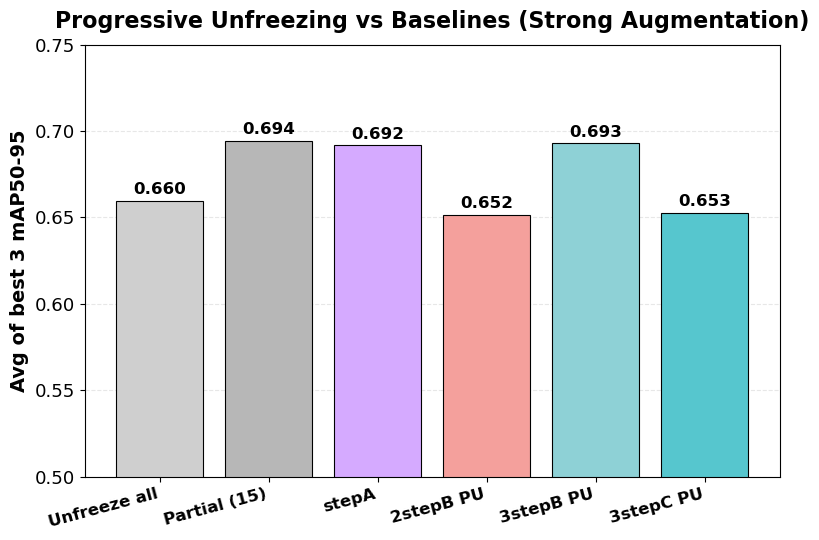

Top-K averages:
  Unfreeze all: 0.659590
  3stepC PU   : 0.652660
  2stepB PU   : 0.651630
  3stepB PU   : 0.693023
  stepA       : 0.691787
  Partial (15): 0.694303


In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

csv_path = "wandb_csv_freezing_strategies2.csv"  # <-- change
K = 3  # <-- choose K

df = pd.read_csv(csv_path)

# Limit to step <= 50 if you want fair comparison across runs
# df["Step"] = pd.to_numeric(df["Step"], errors="coerce")
# df = df[df["Step"] <= 50].copy()

# Keep only main columns (exclude __MIN/__MAX and Step)
metric_cols = [c for c in df.columns if c != "Step" and not c.endswith("__MIN") and not c.endswith("__MAX")]

def topk_mean(series: pd.Series, k: int) -> float:
    s = pd.to_numeric(series, errors="coerce").dropna()
    if s.empty:
        return np.nan
    return float(s.nlargest(min(k, len(s))).mean())

def find_col(contains: str) -> str:
    matches = [c for c in metric_cols if contains in c]
    if not matches:
        raise ValueError(f'No column found containing: "{contains}"')
    if len(matches) > 1:
        print(f'Warning: multiple columns match "{contains}", using first:\n  {matches[0]}')
    return matches[0]

# Map your desired bars to the CSV columns
label_to_col = {
    "Unfreeze all": find_col("yolo_unfz_all_augmentation_strong"),
    "3stepC PU":    find_col("progressive_unfz_stageC2_freeze0"),
    "2stepB PU":    find_col("progressive_unfz_stageB1_freeze0"),
    "3stepB PU":    find_col("progressive_unfz_stageB2_freeze20"),
    "stepA":        find_col("progressive_unfz_stageA"),
    "Partial (15)": find_col("yolo_strong_partial_freeze15"),
}

# Compute Avg of best K
scores = {label: topk_mean(df[col], K) for label, col in label_to_col.items()}

# Order of bars on the x-axis
labels = ["Unfreeze all", "Partial (15)", "stepA", "2stepB PU", "3stepB PU", "3stepC PU"]
values = [scores[l] for l in labels]

# Pastel colors:
# - 2-step process (2stepB PU) = pastel tomato family
# - 3-step process (3stepB/3stepC) = pastel cyan family
# - stepA shared = its own pastel purple
# - baselines = gray variants
colors = {
    "Unfreeze all": "#CFCFCF",   # light gray
    "Partial (15)": "#B7B7B7",   # slightly darker gray
    "stepA":        "#D5AAFF",   # pastel lavender (shared stage)
    "2stepB PU":    "#F4A09C",   # soft tomato (2-step family)
    "3stepB PU":    "#8ED1D6",   # soft cyan (3-step family)
    "3stepC PU":    "#56C6CE",   # slightly deeper cyan (still pastel-ish)
}

plt.figure(figsize=(8, 5.5))

bars = plt.bar(
    labels,
    values,
    color=[colors[l] for l in labels],
    edgecolor="black",
    linewidth=0.8
)

# Value labels (3 decimals, bold, slide-friendly)
for b in bars:
    h = b.get_height()
    if np.isfinite(h):
        plt.text(
            b.get_x() + b.get_width()/2,
            h + 0.002,
            f"{h:.3f}",
            ha="center",
            va="bottom",
            fontsize=12,
            fontweight="bold"
        )

# Style
plt.grid(axis="y", linestyle="--", alpha=0.3)
plt.gca().set_axisbelow(True)

plt.ylabel(f"Avg of best {K} mAP50-95", fontsize=14, fontweight="bold")
plt.title("Progressive Unfreezing vs Baselines (Strong Augmentation)", fontsize=16, fontweight="bold", pad=12)

plt.xticks(fontsize=12, fontweight="bold", rotation=15, ha="right")
plt.yticks(fontsize=13)

# Optional: adjust y-range to your data
plt.ylim(0.5, 0.75)

plt.tight_layout()
plt.show()

print("Top-K averages:")
for k, v in scores.items():
    print(f"  {k:12s}: {v:.6f}")

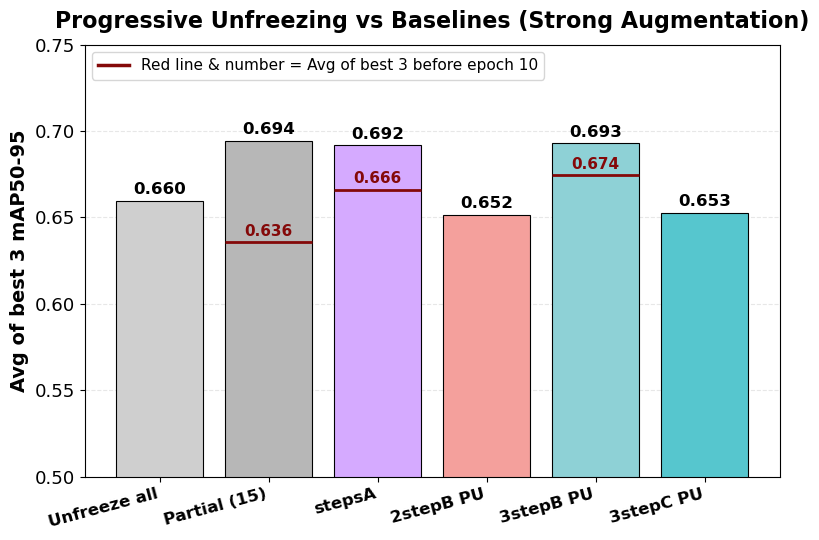

Top-K averages:
  Unfreeze all: 0.659590
  3stepC PU   : 0.652660
  2stepB PU   : 0.651630
  3stepB PU   : 0.693023
  stepsA      : 0.691787
  Partial (15): 0.694303


In [36]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

csv_path = "wandb_csv_freezing_strategies2.csv"
K = 3

df = pd.read_csv(csv_path)

# Ensure Step is numeric
df["Step"] = pd.to_numeric(df["Step"], errors="coerce")

metric_cols = [c for c in df.columns if c != "Step" and not c.endswith("__MIN") and not c.endswith("__MAX")]

def topk_mean(series: pd.Series, k: int) -> float:
    s = pd.to_numeric(series, errors="coerce").dropna()
    if s.empty:
        return np.nan
    return float(s.nlargest(min(k, len(s))).mean())

def mean_first_n_epochs(df_: pd.DataFrame, col: str, n: int = 10) -> float:
    tmp = df_.loc[df_["Step"] <= n, col]
    s = pd.to_numeric(tmp, errors="coerce").dropna()
    return float(s.mean()) if len(s) else np.nan

def find_col(contains: str) -> str:
    matches = [c for c in metric_cols if contains in c]
    if not matches:
        raise ValueError(f'No column found containing: "{contains}"')
    return matches[0]

label_to_col = {
    "Unfreeze all": find_col("yolo_unfz_all_augmentation_strong"),
    "3stepC PU":    find_col("progressive_unfz_stageC2_freeze0"),
    "2stepB PU":    find_col("progressive_unfz_stageB1_freeze0"),
    "3stepB PU":    find_col("progressive_unfz_stageB2_freeze20"),  # stepB2
    "stepsA":        find_col("progressive_unfz_stageA"),
    "Partial (15)": find_col("yolo_strong_partial_freeze15"),
}

# Main bar values: avg of best K
scores = {label: topk_mean(df[col], K) for label, col in label_to_col.items()}

labels = ["Unfreeze all", "Partial (15)", "stepsA", "2stepB PU", "3stepB PU", "3stepC PU"]
values = [scores[l] for l in labels]

colors = {
    "Unfreeze all": "#CFCFCF",
    "Partial (15)": "#B7B7B7",
    "stepsA":        "#D5AAFF",
    "2stepB PU":    "#F4A09C",
    "3stepB PU":    "#8ED1D6",
    "3stepC PU":    "#56C6CE",
}

plt.figure(figsize=(8, 5.5))
xpos = np.arange(len(labels))

bars = plt.bar(
    xpos,
    values,
    color=[colors[l] for l in labels],
    edgecolor="black",
    linewidth=0.8
)

# Bar labels (top-K)
for b in bars:
    h = b.get_height()
    if np.isfinite(h):
        plt.text(
            b.get_x() + b.get_width()/2,
            h + 0.002,
            f"{h:.3f}",
            ha="center",
            va="bottom",
            fontsize=12,
            fontweight="bold"
        )

# ---- NEW: early average marker for first 10 epochs ----
N_EPOCHS = 10
mark_labels = {"Partial (15)", "stepsA", "3stepB PU"}  # only these three

for i, lab in enumerate(labels):
    if lab not in mark_labels:
        continue

    col = label_to_col[lab]
    early = mean_first_n_epochs(df, col, N_EPOCHS)
    if not np.isfinite(early):
        continue

    # horizontal line across the bar width
    left = bars[i].get_x()
    right = left + bars[i].get_width()
    plt.hlines(early, left, right, colors="#840909", linewidth=2.0)

    # numeric label near the line (slightly above)
    plt.text(
        (left + right) / 2,
        early + 0.002,
        f"{early:.3f}",
        ha="center",
        va="bottom",
        fontsize=11,
        fontweight="bold",
        color= "#840909"
    )

# Style
plt.grid(axis="y", linestyle="--", alpha=0.3)
plt.gca().set_axisbelow(True)

plt.ylabel(f"Avg of best {K} mAP50-95", fontsize=14, fontweight="bold")
plt.title("Progressive Unfreezing vs Baselines (Strong Augmentation)", fontsize=16, fontweight="bold", pad=12)

plt.xticks(xpos, labels, fontsize=12, fontweight="bold", rotation=15, ha="right")
plt.yticks(fontsize=13)
plt.ylim(0.5, 0.75)

# Small note for clarity (optional)
# plt.figtext(0.5, 0.01, f"Black line = mean mAP over first {N_EPOCHS} epochs (Steps 1–{N_EPOCHS})",
#             ha="center", fontsize=10)
from matplotlib.lines import Line2D

legend_line = Line2D([0], [0], color='#840909', linewidth=2.5)
plt.legend(
    [legend_line],
    [f"Red line & number = Avg of best {K} before epoch {N_EPOCHS}"],
    loc="upper left",
    fontsize=11,
    frameon=True
)
plt.tight_layout()
plt.show()

print("Top-K averages:")
for k, v in scores.items():
    print(f"  {k:12s}: {v:.6f}")

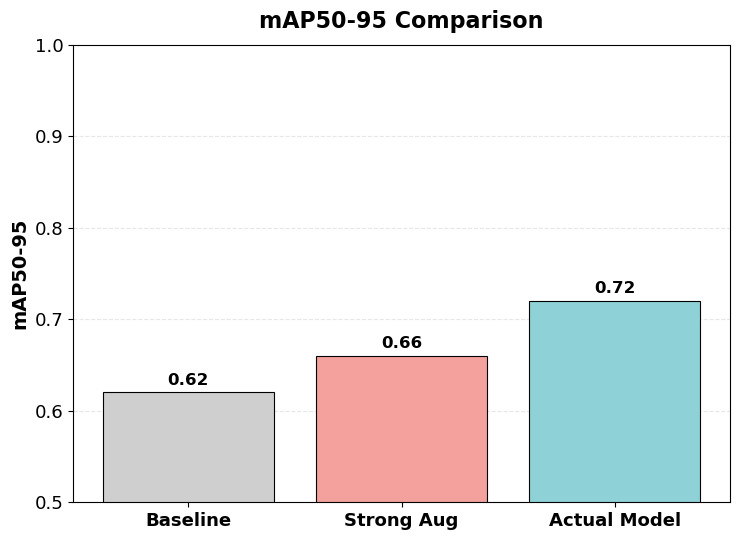

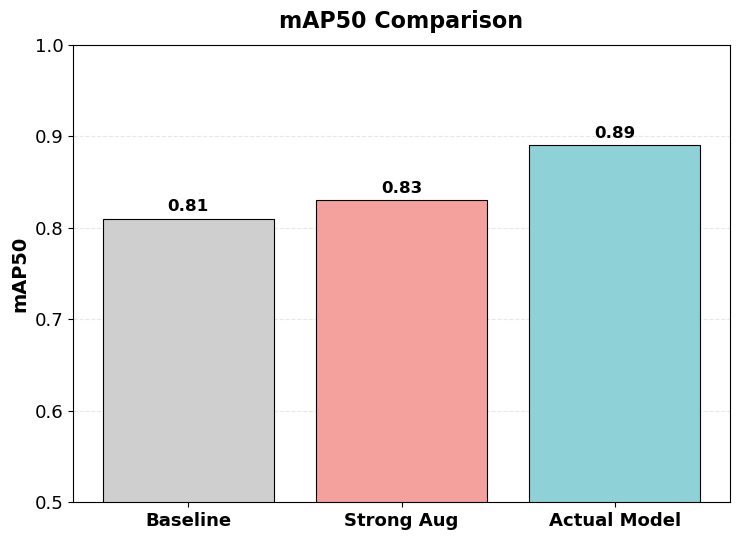

In [41]:
import matplotlib.pyplot as plt
import numpy as np

# Values
strong_aug = {"mAP50-95": 0.66, "mAP50": 0.83}
best = {"mAP50-95": 0.72, "mAP50": 0.89}
baseline = {"mAP50-95": 0.62, "mAP50": 0.81}

labels = ["Baseline", "Strong Aug", "Actual Model"]

colors = {
    "Baseline": "#CFCFCF",     # soft gray
    "Strong Aug": "#F4A09C",   # soft tomato
    "Actual Model": "#8ED1D6",   # soft cyan
}

def plot_metric(metric_name):
    values = [
        baseline[metric_name],
        strong_aug[metric_name],
        best[metric_name],
    ]

    plt.figure(figsize=(7.5, 5.5))

    bars = plt.bar(
        labels,
        values,
        color=[colors[l] for l in labels],
        edgecolor="black",
        linewidth=0.8
    )

    # Value labels
    for b in bars:
        h = b.get_height()
        plt.text(
            b.get_x() + b.get_width()/2,
            h + 0.005,
            f"{h:.2f}",
            ha="center",
            va="bottom",
            fontsize=12,
            fontweight="bold"
        )

    plt.grid(axis="y", linestyle="--", alpha=0.3)
    plt.gca().set_axisbelow(True)

    plt.ylabel(metric_name, fontsize=14, fontweight="bold")
    plt.title(f"{metric_name} Comparison", fontsize=16, fontweight="bold", pad=12)

    plt.xticks(fontsize=13, fontweight="bold")
    plt.yticks(fontsize=13)
    plt.ylim(0.5, 1)

    plt.tight_layout()
    plt.show()

# Plot both
plot_metric("mAP50-95")
plot_metric("mAP50")


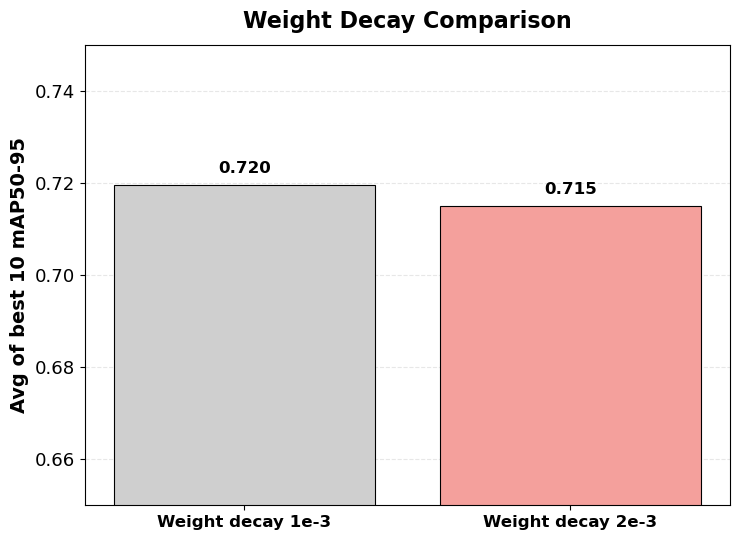

Top-K averages:
Weight decay 1e-3: 0.719518
Weight decay 2e-3: 0.714899


In [47]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

csv_path = "wandb_csv_weight_decay.csv"  # <-- change
K = 10  # <-- choose K

df = pd.read_csv(csv_path)
df["Step"] = pd.to_numeric(df["Step"], errors="coerce")

# Keep only main metric columns
metric_cols = [
    c for c in df.columns
    if c != "Step" and not c.endswith("__MIN") and not c.endswith("__MAX")
]

def topk_mean(series: pd.Series, k: int) -> float:
    s = pd.to_numeric(series, errors="coerce").dropna()
    if s.empty:
        return np.nan
    return float(s.nlargest(min(k, len(s))).mean())

def find_col(contains: str) -> str:
    matches = [c for c in metric_cols if contains in c]
    if not matches:
        raise ValueError(f'No column found containing: "{contains}"')
    return matches[0]

# Identify weight decay columns
col_1e3 = find_col("wd1e-3")
col_2e3 = find_col("wd2e-3")

scores = {
    "Weight decay 1e-3": topk_mean(df[col_1e3], K),
    "Weight decay 2e-3": topk_mean(df[col_2e3], K),
}

labels = list(scores.keys())
values = list(scores.values())

colors = {
    "Weight decay 1e-3": "#CFCFCF",   # soft cyan
    "Weight decay 2e-3": "#F4A09C",   # soft tomato
}

plt.figure(figsize=(7.5, 5.5))

bars = plt.bar(
    labels,
    values,
    color=[colors[l] for l in labels],
    edgecolor="black",
    linewidth=0.8
)

# Value labels
for b in bars:
    h = b.get_height()
    if np.isfinite(h):
        plt.text(
            b.get_x() + b.get_width()/2,
            h + 0.002,
            f"{h:.3f}",
            ha="center",
            va="bottom",
            fontsize=12,
            fontweight="bold"
        )

plt.grid(axis="y", linestyle="--", alpha=0.3)
plt.gca().set_axisbelow(True)

plt.ylabel(f"Avg of best {K} mAP50-95", fontsize=14, fontweight="bold")
plt.title("Weight Decay Comparison", fontsize=16, fontweight="bold", pad=12)

plt.xticks(fontsize=12, fontweight="bold")
plt.yticks(fontsize=13)
plt.ylim(0.65, 0.75)  # adjust if needed

plt.tight_layout()
plt.show()

print("Top-K averages:")
for k, v in scores.items():
    print(f"{k}: {v:.6f}")

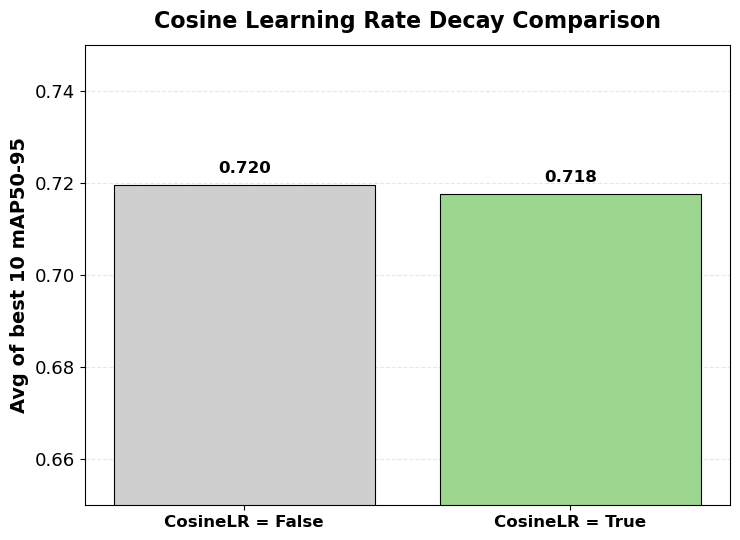

Top-K averages:
CosineLR = False: 0.719518
CosineLR = True: 0.717573


In [48]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

csv_path = "wandb_csv_cosinelr.csv"  # <-- change
K = 10  # <-- choose K

df = pd.read_csv(csv_path)
df["Step"] = pd.to_numeric(df["Step"], errors="coerce")

# Keep only main metric columns
metric_cols = [
    c for c in df.columns
    if c != "Step" and not c.endswith("__MIN") and not c.endswith("__MAX")
]

def topk_mean(series: pd.Series, k: int) -> float:
    s = pd.to_numeric(series, errors="coerce").dropna()
    if s.empty:
        return np.nan
    return float(s.nlargest(min(k, len(s))).mean())

def find_col(contains: str) -> str:
    matches = [c for c in metric_cols if contains in c]
    if not matches:
        raise ValueError(f'No column found containing: "{contains}"')
    return matches[0]

# Identify columns
col_no_cos = find_col("LR_1e-3")         # CosineLR = False
col_cos    = find_col("coslr")           # CosineLR = True

scores = {
    "CosineLR = False": topk_mean(df[col_no_cos], K),
    "CosineLR = True":  topk_mean(df[col_cos], K),
}

labels = list(scores.keys())
values = list(scores.values())

colors = {
    "CosineLR = False": "#CFCFCF",  # soft gray
    "CosineLR = True":  "#9CD68E",  # soft cyan
}

plt.figure(figsize=(7.5, 5.5))

bars = plt.bar(
    labels,
    values,
    color=[colors[l] for l in labels],
    edgecolor="black",
    linewidth=0.8
)

# Value labels
for b in bars:
    h = b.get_height()
    if np.isfinite(h):
        plt.text(
            b.get_x() + b.get_width()/2,
            h + 0.002,
            f"{h:.3f}",
            ha="center",
            va="bottom",
            fontsize=12,
            fontweight="bold"
        )

plt.grid(axis="y", linestyle="--", alpha=0.3)
plt.gca().set_axisbelow(True)

plt.ylabel(f"Avg of best {K} mAP50-95", fontsize=14, fontweight="bold")
plt.title("Cosine Learning Rate Decay Comparison", fontsize=16, fontweight="bold", pad=12)

plt.xticks(fontsize=12, fontweight="bold")
plt.yticks(fontsize=13)
plt.ylim(0.65, 0.75)  # adjust if needed

plt.tight_layout()
plt.show()

print("Top-K averages:")
for k, v in scores.items():
    print(f"{k}: {v:.6f}")

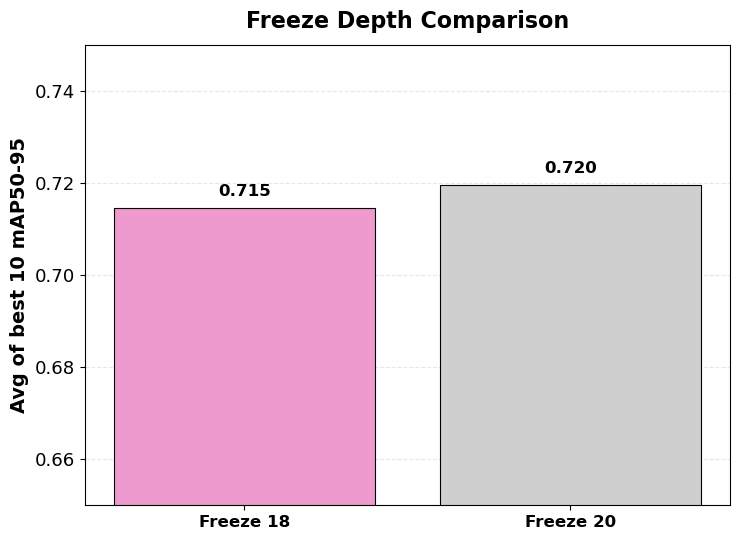

Top-K averages:
Freeze 18: 0.714539
Freeze 20: 0.719518


In [50]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

csv_path = "wandb_csv_freeze.csv"  # <-- change
K = 10  # <-- choose K

df = pd.read_csv(csv_path)
df["Step"] = pd.to_numeric(df["Step"], errors="coerce")

# Keep only main metric columns
metric_cols = [
    c for c in df.columns
    if c != "Step" and not c.endswith("__MIN") and not c.endswith("__MAX")
]

def topk_mean(series: pd.Series, k: int) -> float:
    s = pd.to_numeric(series, errors="coerce").dropna()
    if s.empty:
        return np.nan
    return float(s.nlargest(min(k, len(s))).mean())

def find_col(contains: str) -> str:
    matches = [c for c in metric_cols if contains in c]
    if not matches:
        raise ValueError(f'No column found containing: "{contains}"')
    return matches[0]

# Identify columns
col_18 = find_col("freeze18")
col_20 = find_col("freeze20")

scores = {
    "Freeze 18": topk_mean(df[col_18], K),
    "Freeze 20": topk_mean(df[col_20], K),
}

labels = list(scores.keys())
values = list(scores.values())

# Pastel colors
colors = {
    "Freeze 18": "#EE9ACE",  # soft tomato
    "Freeze 20": "#CFCFCF",  # soft cyan
}

plt.figure(figsize=(7.5, 5.5))

bars = plt.bar(
    labels,
    values,
    color=[colors[l] for l in labels],
    edgecolor="black",
    linewidth=0.8
)

# Value labels
for b in bars:
    h = b.get_height()
    if np.isfinite(h):
        plt.text(
            b.get_x() + b.get_width()/2,
            h + 0.002,
            f"{h:.3f}",
            ha="center",
            va="bottom",
            fontsize=12,
            fontweight="bold"
        )

plt.grid(axis="y", linestyle="--", alpha=0.3)
plt.gca().set_axisbelow(True)

plt.ylabel(f"Avg of best {K} mAP50-95", fontsize=14, fontweight="bold")
plt.title("Freeze Depth Comparison", fontsize=16, fontweight="bold", pad=12)

plt.xticks(fontsize=12, fontweight="bold")
plt.yticks(fontsize=13)
plt.ylim(0.65, 0.75)  # adjust if needed

plt.tight_layout()
plt.show()

print("Top-K averages:")
for k, v in scores.items():
    print(f"{k}: {v:.6f}")

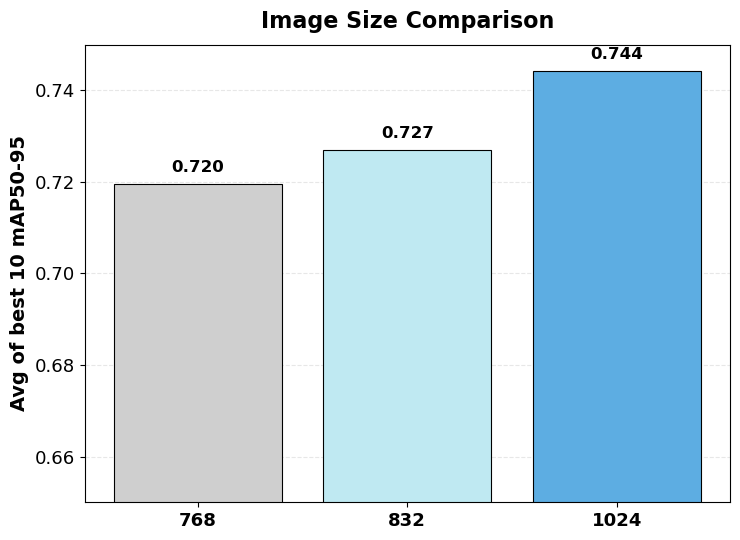

Top-K averages:
768: 0.719518
832: 0.726933
1024: 0.744167


In [53]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

csv_path = "wandb_csv_imagesz_1024.csv"  # <-- change
K = 10  # <-- choose K

df = pd.read_csv(csv_path)
df["Step"] = pd.to_numeric(df["Step"], errors="coerce")

# Keep only main metric columns
metric_cols = [
    c for c in df.columns
    if c != "Step" and not c.endswith("__MIN") and not c.endswith("__MAX")
]

def topk_mean(series: pd.Series, k: int) -> float:
    s = pd.to_numeric(series, errors="coerce").dropna()
    if s.empty:
        return np.nan
    return float(s.nlargest(min(k, len(s))).mean())

def find_col(contains: str) -> str:
    matches = [c for c in metric_cols if contains in c]
    if not matches:
        raise ValueError(f'No column found containing: "{contains}"')
    return matches[0]

# Identify columns
col_768  = find_col("img768")
col_832  = find_col("img832")
col_1024 = find_col("img1024")

scores = {
    "768":  topk_mean(df[col_768], K),
    "832":  topk_mean(df[col_832], K),
    "1024": topk_mean(df[col_1024], K),
}

labels = ["768", "832", "1024"]
values = [scores[l] for l in labels]

colors = {
    "768":  "#CFCFCF",   # gray
    "832":  "#BFE9F2",   # light blue
    "1024": "#5DADE2",   # bluish
}

plt.figure(figsize=(7.5, 5.5))

bars = plt.bar(
    labels,
    values,
    color=[colors[l] for l in labels],
    edgecolor="black",
    linewidth=0.8
)

# Value labels
for b in bars:
    h = b.get_height()
    if np.isfinite(h):
        plt.text(
            b.get_x() + b.get_width()/2,
            h + 0.002,
            f"{h:.3f}",
            ha="center",
            va="bottom",
            fontsize=12,
            fontweight="bold"
        )

plt.grid(axis="y", linestyle="--", alpha=0.3)
plt.gca().set_axisbelow(True)

plt.ylabel(f"Avg of best {K} mAP50-95", fontsize=14, fontweight="bold")
plt.title("Image Size Comparison", fontsize=16, fontweight="bold", pad=12)

plt.xticks(fontsize=13, fontweight="bold")
plt.yticks(fontsize=13)

plt.ylim(0.65, 0.75)  # adjust if needed

plt.tight_layout()
plt.show()

print("Top-K averages:")
for k, v in scores.items():
    print(f"{k}: {v:.6f}")